In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Step 1: Environment Setup & Data Extraction

In [ ]:
#from google.colab import drive
drive.mount('/content/drive')


#Imports

import os
import zipfile
import numpy as np

#PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

#Image Processing
from torchvision import transforms
from PIL import Image

#Visualization & Evaluation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


#Configure Device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


#Extract Dataset

zip_path = '/content/drive/MyDrive/archive (6).zip'
extract_path = '/content/blood_cells_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Dataset extracted to: {extract_path}")


base_path = '/content/blood_cells_data/dataset2-master/dataset2-master/images'

train_dir = os.path.join(base_path, 'TRAIN')
test_dir = os.path.join(base_path, 'TEST')

#Verify paths
if os.path.exists(train_dir):

    classes = sorted(os.listdir(train_dir))

    print("Paths are correct!")
    print(f"Detected classes: {classes}")
    print(f"Using device: {device}")

else:
    print("Path error. Please check extracted folders.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset extracted to: /content/blood_cells_data
Paths are correct!
Detected classes: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
Using device: cpu


Step 2: Custom Dataset Class & Sample Visualizatio

 Total images found in dataset: 9957
 Data Distribution per class:
 - EOSINOPHIL: 2497 images
 - LYMPHOCYTE: 2483 images
 - MONOCYTE: 2478 images
 - NEUTROPHIL: 2499 images


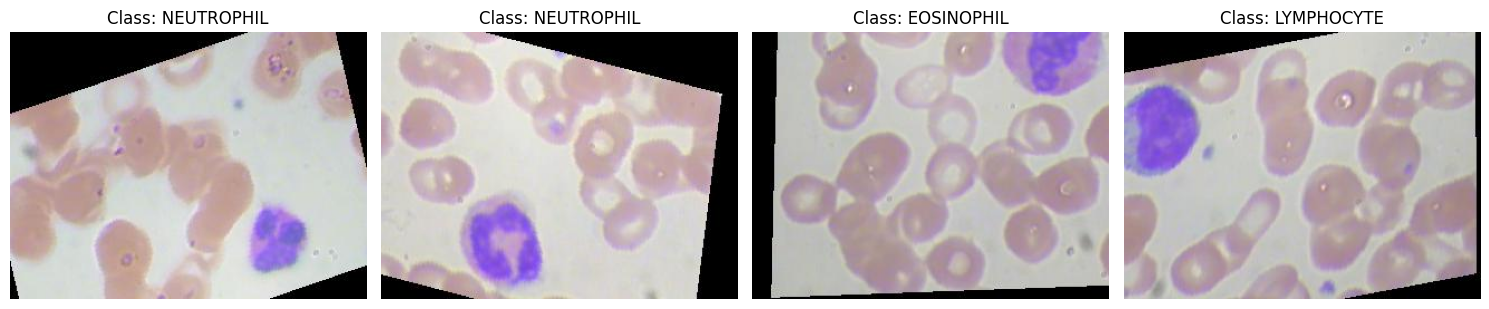

In [ ]:
# Custom dataset class to load blood cell images properly
class BloodCellDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        # Get sorted class names (folders)
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        # Loop through categories and collect image paths and corresponding labels
        for cls_name in self.classes:
            category_path = os.path.join(root_dir, cls_name)
            for img_name in os.listdir(category_path):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(os.path.join(category_path, img_name))
                    self.labels.append(self.class_to_idx[cls_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

# Statistical analysis to verify dataset data and ensure balance
raw_dataset = BloodCellDataset(root_dir=train_dir)
print(f" Total images found in dataset: {len(raw_dataset)}")

class_counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in raw_dataset.classes}
print(" Data Distribution per class:")
for cls, count in class_counts.items():
    print(f" - {cls}: {count} images")

# Displaying random visual samples for initial data exploration
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for i in range(4):
    random_idx = np.random.randint(0, len(raw_dataset))
    img, label = raw_dataset[random_idx]

    # FIX: Convert PyTorch tensor dimensions [C, H, W] to Matplotlib standard [H, W, C]
    if isinstance(img, torch.Tensor):
        img = img.permute(1, 2, 0).numpy()

    axes[i].imshow(img)
    axes[i].set_title(f"Class: {raw_dataset.classes[label]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

 Total images found in training directory: 9957


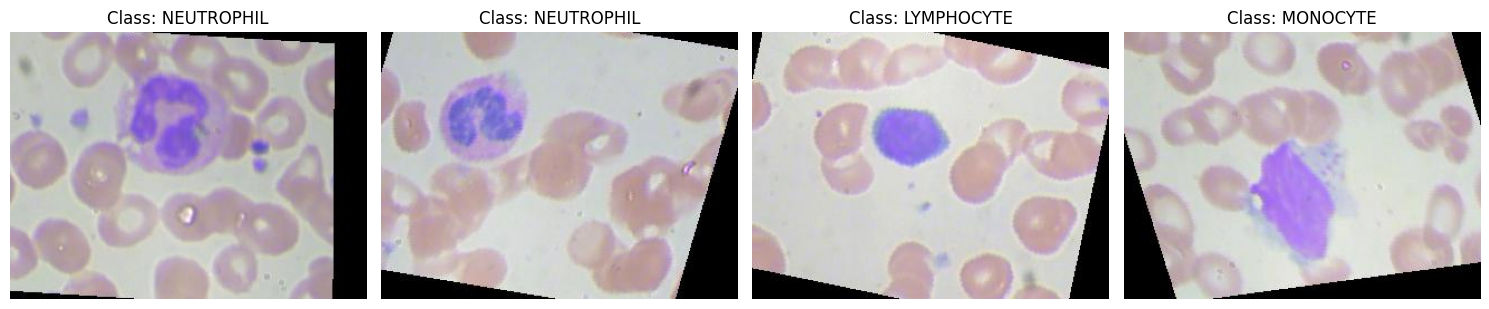

In [ ]:
# Load raw data for exploration (without complex training augmentations)
raw_dataset = BloodCellDataset(root_dir=train_dir)

print(f" Total images found in training directory: {len(raw_dataset)}")

fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for i in range(4):
    random_idx = np.random.randint(0, len(raw_dataset))
    img, label = raw_dataset[random_idx] # Get the image and its corresponding label index

    class_name = raw_dataset.classes[label]



    axes[i].imshow(img)
    axes[i].set_title(f"Class: {class_name}")
    axes[i].axis('off') # Hide the axes for a cleaner look



plt.tight_layout()
plt.show() # Display the final plot

In [ ]:
# Check class distribution to ensure data balance and prevent class imbalanceclass_counts = {}
for cls in raw_dataset.classes:

    count = len(os.listdir(os.path.join(train_dir, cls)))
    class_counts[cls] = count

print(" Data Distribution per class:")
for cls, count in class_counts.items():
    print(f" - {cls}: {count} images")


sample_img, sample_label = raw_dataset[0]
img_width, img_height = sample_img.size


print(f"\n Original image size: {img_width}x{img_height}")

# Final data integrity check to ensure no empty folders obstruct training
if min(class_counts.values()) > 0:
    print("\n Integrity Check Passed: All classes contain images.")
else:
    print("\n Warning: Some folders are empty, please check the extraction path.")

 Data Distribution per class:
 - EOSINOPHIL: 2497 images
 - LYMPHOCYTE: 2483 images
 - MONOCYTE: 2478 images
 - NEUTROPHIL: 2499 images

 Original image size: 320x240

 Integrity Check Passed: All classes contain images.


Step 3: Image Processing & Data Splitting (70/15/15)

In [ ]:

# Define essential transformations for image preprocessing
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)), # Resizing
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) #Normalization
])

raw_dataset.transform = train_transforms

# 3. Calculate sizes using the Professor's exact formula (70%, 15%, 15%)
train_size = int(0.7 * len(raw_dataset))
val_size = int(0.15 * len(raw_dataset))
test_size = len(raw_dataset) - train_size - val_size


train_data, val_data, test_data = random_split(raw_dataset, [train_size, val_size, test_size])


train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(f" Training set (70%): {len(train_data)}")
print(f" Validation set (15%): {len(val_data)}")
print(f" Test set (15%): {len(test_data)}")

 Training set (70%): 6969
 Validation set (15%): 1493
 Test set (15%): 1495


Step 4: CNN Model Architecture Design

In [ ]:

# Step: Define the CNN Model Architecture

class BloodCellCNN(nn.Module):
    def __init__(self):
        super(BloodCellCNN, self).__init__()

        # 1. Convolutional Layers (استخراج ميزات الصور)
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        # 2. Pooling Layer (تقليل الأبعاد)
        self.pool = nn.MaxPool2d(2, 2)

        # 3. Fully Connected Layers (التصنيف النهائي)
        self.fc1 = nn.Linear(32 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 4) # 4 مخرجات لأن لدينا 4 أنواع خلايا

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(-1, 32 * 32 * 32)
        x = F.relu(self.fc1(x)) #استخدمنا اكتشفيشن فانشين ري لور
        x = self.fc2(x)
        return x

model = BloodCellCNN()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f" Model 'BloodCellCNN' is ready on: {device}")

 Model 'BloodCellCNN' is ready on: cpu


Step 5: Model Training & Validation with Monitoring

In [ ]:
import torch
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 8


history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(" Training and Validation Process Started...")
for epoch in range(num_epochs):
   #  Actual Training Phase and Weights Update
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
#  Immediate Validation Phase for Intermediary Performance Evaluation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # # Calculate and log accuracy and loss metrics for each training epoch
    t_loss = train_loss / len(train_loader)
    t_acc = 100 * train_correct / train_total
    v_loss = val_loss / len(val_loader)
    v_acc = 100 * val_correct / val_total

    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]:")
    print(f"  Train -> Loss: {t_loss:.4f}, AccuracyA: {t_acc:.2f}%")
    print(f"  Val   -> Loss: {v_loss:.4f}, ccuracy: {v_acc:.2f}%")
    print("-" * 40)

print(" Training and Validation Loops Executed Successfully!")

 Training and Validation Process Started...
Epoch [1/8]:
  Train -> Loss: 0.0800, AccuracyA: 97.40%
  Val   -> Loss: 0.5279, ccuracy: 83.39%
----------------------------------------
Epoch [2/8]:
  Train -> Loss: 0.0318, AccuracyA: 99.12%
  Val   -> Loss: 0.7650, ccuracy: 78.63%
----------------------------------------
Epoch [3/8]:
  Train -> Loss: 0.0170, AccuracyA: 99.70%
  Val   -> Loss: 0.6470, ccuracy: 82.38%
----------------------------------------
Epoch [4/8]:
  Train -> Loss: 0.0263, AccuracyA: 99.37%
  Val   -> Loss: 0.7684, ccuracy: 81.65%
----------------------------------------
Epoch [5/8]:
  Train -> Loss: 0.0322, AccuracyA: 99.00%
  Val   -> Loss: 0.8079, ccuracy: 77.49%
----------------------------------------
Epoch [6/8]:
  Train -> Loss: 0.0341, AccuracyA: 98.91%
  Val   -> Loss: 0.6834, ccuracy: 82.65%
----------------------------------------
Epoch [7/8]:
  Train -> Loss: 0.0030, AccuracyA: 99.97%
  Val   -> Loss: 0.7025, ccuracy: 83.66%
-------------------------------

Step 6: Final Evaluation & Visual Analysis

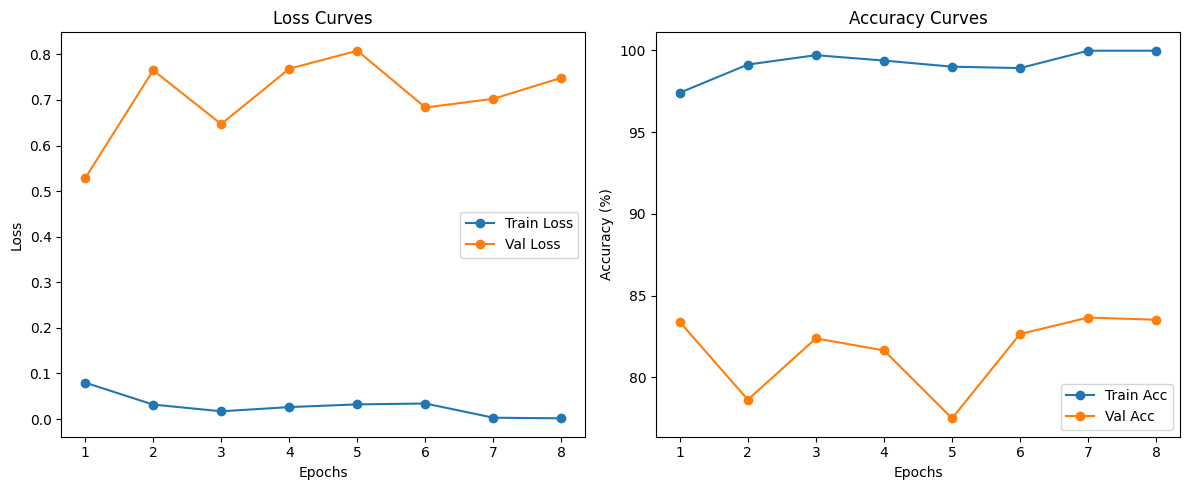

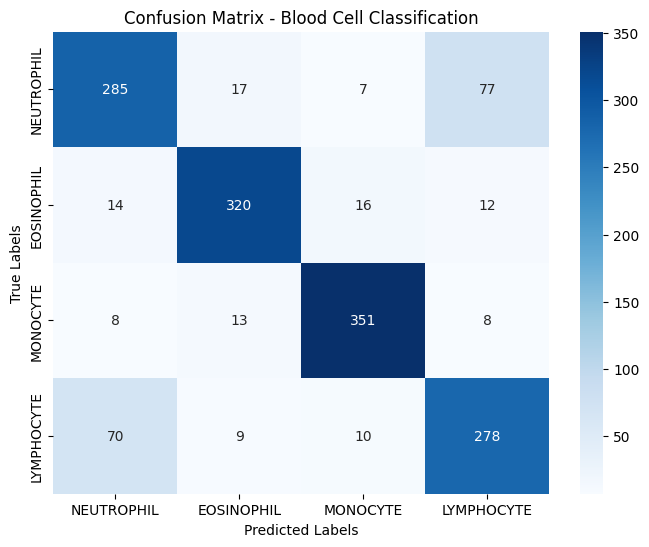


Final Classification Report:
              precision    recall  f1-score   support

  NEUTROPHIL       0.76      0.74      0.75       386
  EOSINOPHIL       0.89      0.88      0.89       362
    MONOCYTE       0.91      0.92      0.92       380
  LYMPHOCYTE       0.74      0.76      0.75       367

    accuracy                           0.83      1495
   macro avg       0.83      0.83      0.83      1495
weighted avg       0.83      0.83      0.83      1495



In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import torch

# 1. Plot performance curves for training history analysis
plt.figure(figsize=(12, 5))

# Plot training vs validation loss curves
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), history['train_loss'], label='Train Loss', marker='o')
plt.plot(range(1, num_epochs+1), history['val_loss'], label='Val Loss', marker='o')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot training vs validation accuracy curves
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), history['train_acc'], label='Train Acc', marker='o')
plt.plot(range(1, num_epochs+1), history['val_acc'], label='Val Acc', marker='o')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

# 2. Evaluate model performance comprehensively on the test set
model.eval()
all_predictions, all_true_labels = [], []
class_names = ['NEUTROPHIL', 'EOSINOPHIL', 'MONOCYTE', 'LYMPHOCYTE']

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())

# 3. Generate and plot the final confusion matrix heatmap
cm = confusion_matrix(all_true_labels, all_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Blood Cell Classification')
plt.show()

# 4. Display detailed metrics using the classification report
print("\nFinal Classification Report:")
print(classification_report(all_true_labels, all_predictions, target_names=class_names))

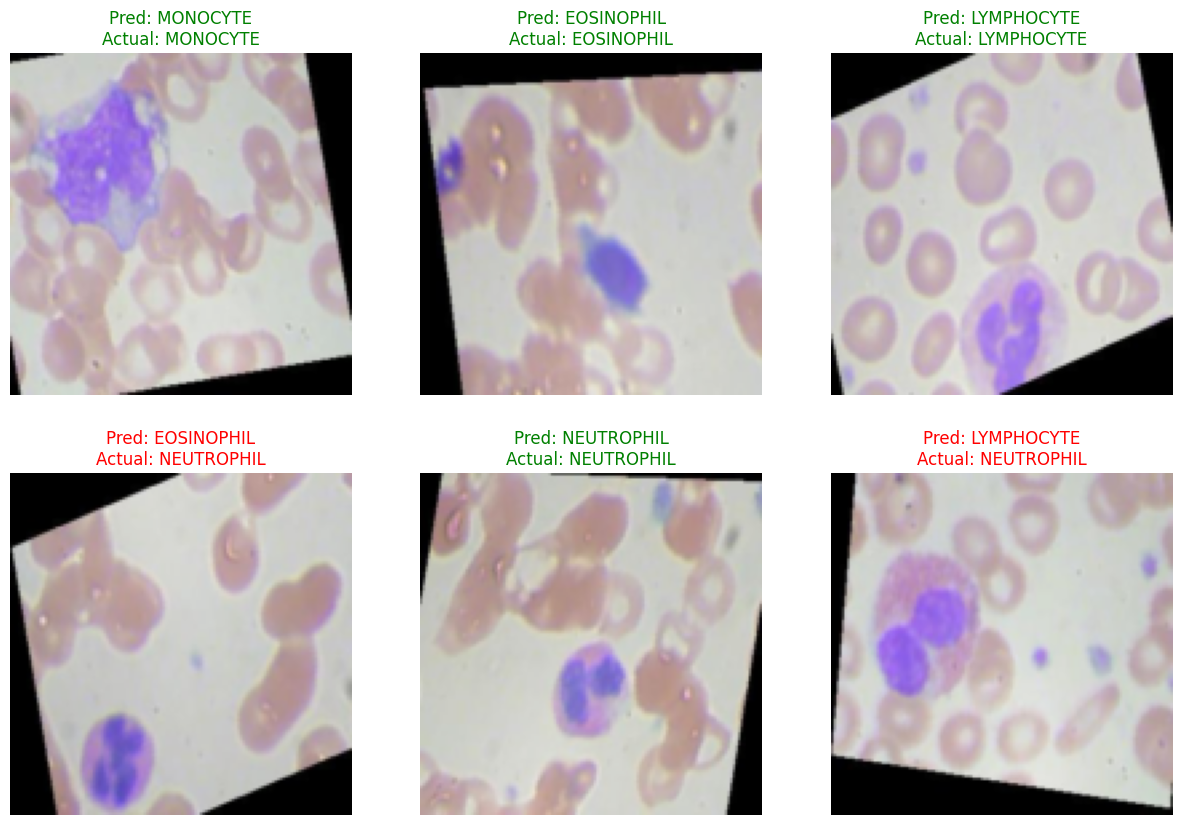

In [ ]:

# 1. Function to display and interpret random model test predictions (Visualizing Predictions)
def visualize_predictions(model, test_loader, num_images=6):
    model.eval()
    images_so_far = 0

    plt.figure(figsize=(15, 10))


    with torch.no_grad():
        for i, (images, labels) in enumerate(test_loader):

            images, labels = images.to(device), labels.to(device)


            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            for j in range(images.size()[0]):
                images_so_far += 1


                ax = plt.subplot(2, num_images//2, images_so_far)
                ax.axis('off')

                img = images.cpu().data[j].numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)


                color = 'green' if preds[j] == labels[j] else 'red'


                ax.set_title(f'Pred: {class_names[preds[j]]}\nActual: {class_names[labels[j]]}', color=color)


                plt.imshow(img)


                if images_so_far == num_images:
                    return

visualize_predictions(model, test_loader)
plt.show()